<a href="https://colab.research.google.com/github/ajmalbiju56/ML/blob/main/student_per.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data preprocessing

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.copy_on_write = True
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestRegressor


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/student-por.csv")
print(df)

    school sex  age address famsize Pstatus  Medu  Fedu      Mjob      Fjob  \
0       GP   F   18       U     GT3       A     4     4   at_home   teacher   
1       GP   F   17       U     GT3       T     1     1   at_home     other   
2       GP   F   15       U     LE3       T     1     1   at_home     other   
3       GP   F   15       U     GT3       T     4     2    health  services   
4       GP   F   16       U     GT3       T     3     3     other     other   
..     ...  ..  ...     ...     ...     ...   ...   ...       ...       ...   
644     MS   F   19       R     GT3       T     2     3  services     other   
645     MS   F   18       U     LE3       T     3     1   teacher  services   
646     MS   F   18       U     GT3       T     1     1     other     other   
647     MS   M   17       U     LE3       T     3     1  services  services   
648     MS   M   18       R     LE3       T     3     2  services     other   

     ... famrel freetime  goout  Dalc  Walc health 

In [ ]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [ ]:
df.dtypes

,0
school,object
sex,object
age,int64
address,object
famsize,object
Pstatus,object
Medu,int64
Fedu,int64
Mjob,object
Fjob,object


In [ ]:
df['Dalc'].nunique()

5

In [ ]:
df['Dalc'].unique()

array([1, 2, 5, 3, 4])

In [ ]:
df['Dalc'].value_counts()

,count
Dalc,
1,451
2,121
3,43
5,17
4,17


# univariate analysis

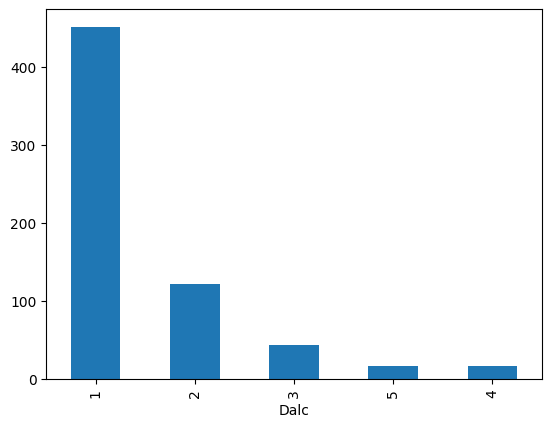

In [ ]:
df['Dalc'].value_counts().plot(kind='bar')
plt.show()

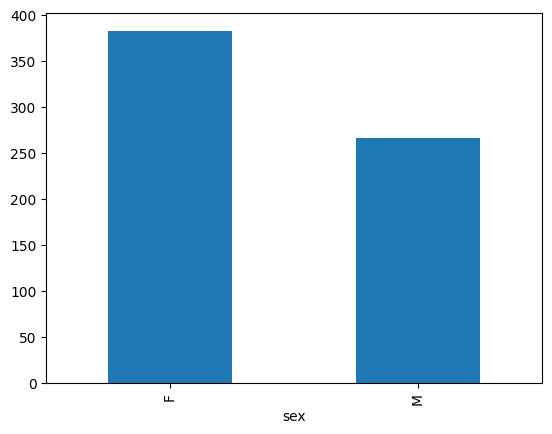

In [ ]:
df['sex'].value_counts().plot(kind='bar')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

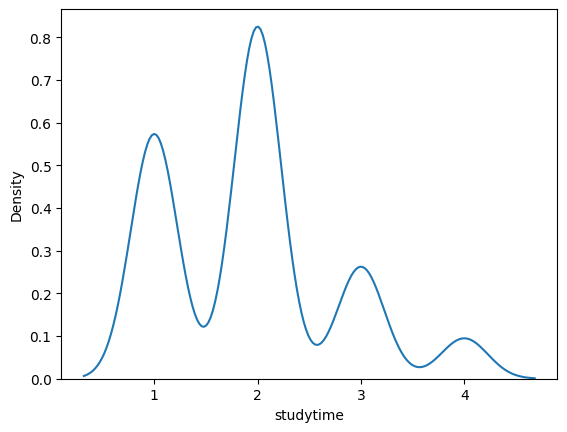

In [ ]:
sns.kdeplot(df['studytime'])
plt.show

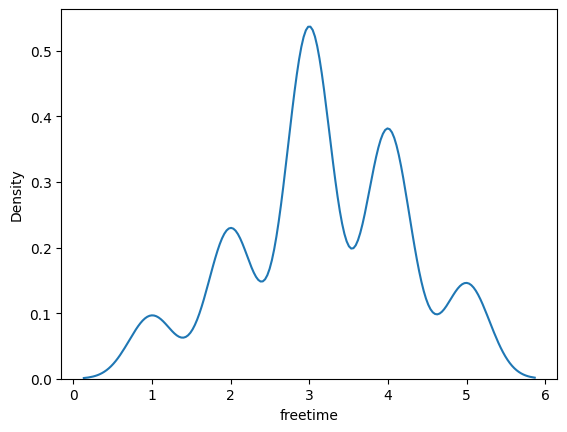

In [ ]:
sns.kdeplot(df['freetime'])
plt.show()

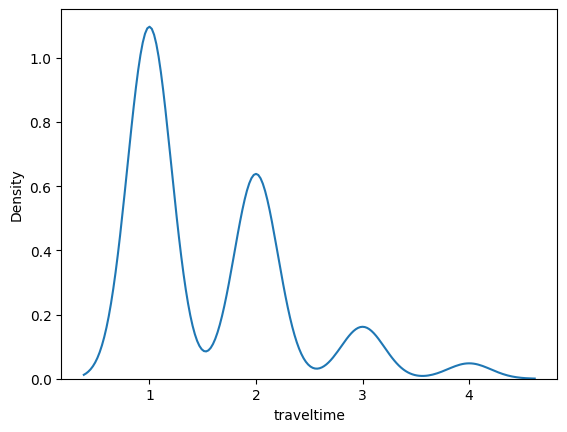

In [ ]:
sns.kdeplot(df['traveltime'])
plt.show()

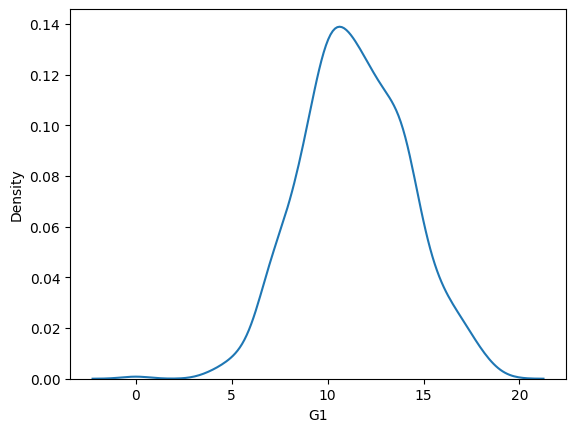

In [ ]:
sns.kdeplot(df['G1'])
plt.show()

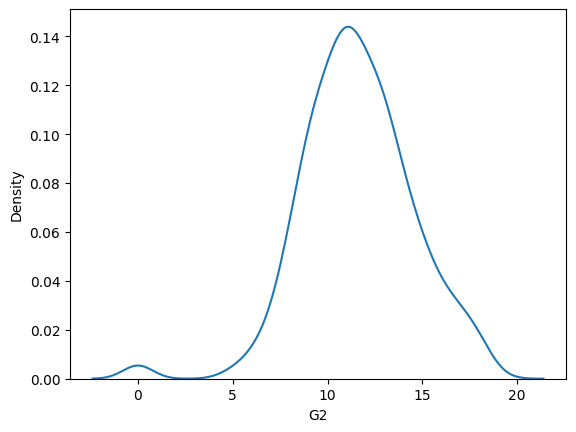

In [ ]:
sns.kdeplot(df['G2'])
plt.show()

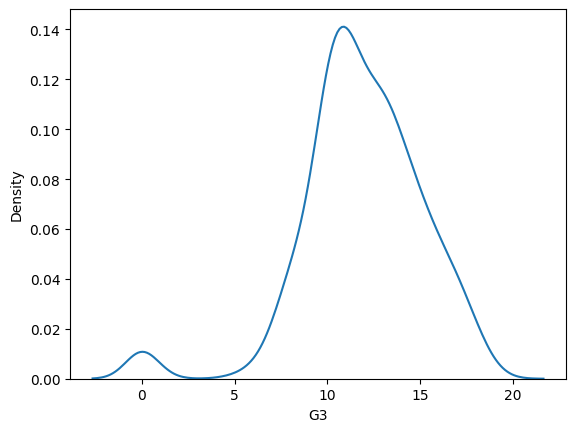

In [ ]:
sns.kdeplot(df['G3'])
plt.show()

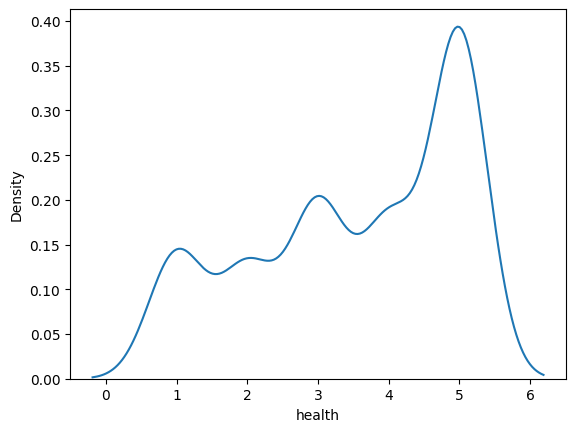

In [ ]:
sns.kdeplot(df['health'])
plt.show()

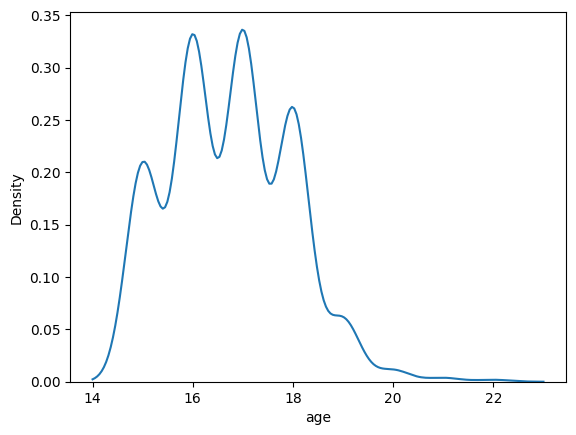

In [ ]:
sns.kdeplot(df['age'])
plt.show()

# bivariate analysis

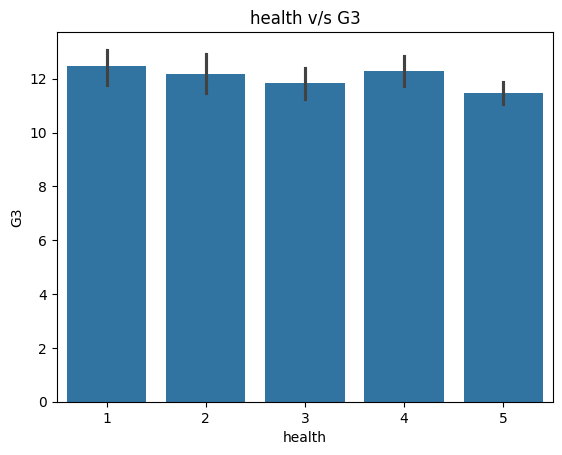

In [ ]:
sns.barplot(data=df,x='health',y='G3')
plt.title("health v/s G3")
plt.show()

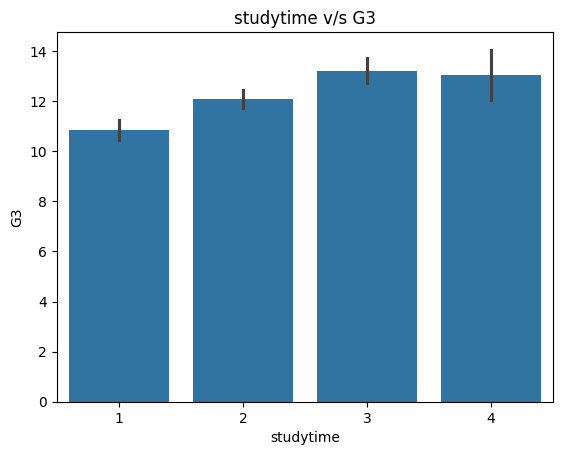

In [ ]:
sns.barplot(data=df,x='studytime',y='G3')
plt.title("studytime v/s G3")
plt.show()

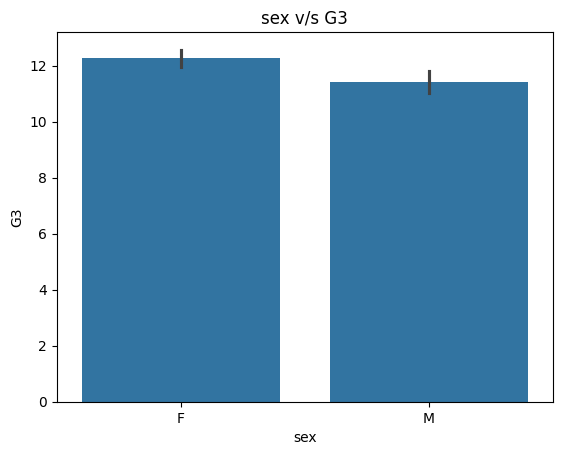

In [ ]:
sns.barplot(data=df,x='sex',y='G3')
plt.title("sex v/s G3")
plt.show()

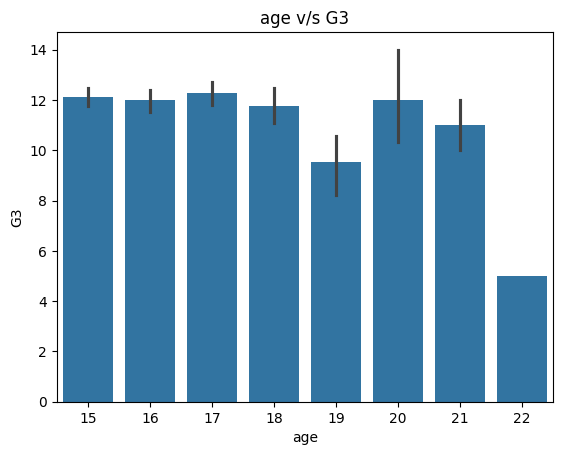

In [ ]:
sns.barplot(data=df,x='age',y='G3')
plt.title("age v/s G3")
plt.show()

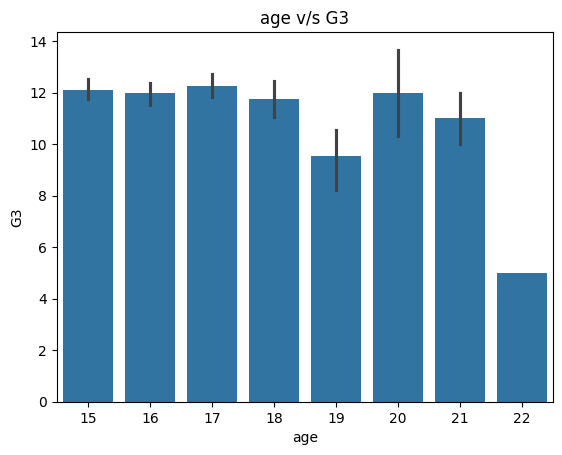

In [ ]:
sns.barplot(data=df,x='age',y='G3')
plt.title("age v/s G3")
plt.show()

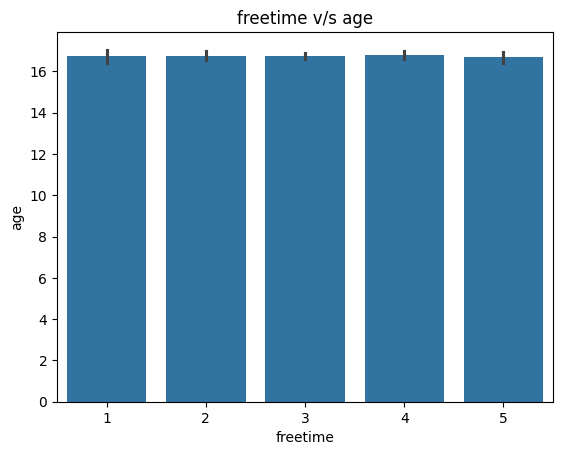

In [ ]:
sns.barplot(data=df,x='freetime',y='age')
plt.title("freetime v/s age")
plt.show()

# multivariate analysis

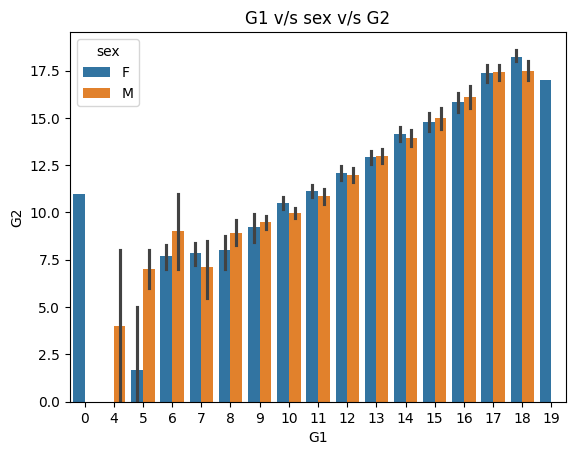

In [ ]:
sns.barplot(data=df,x='G1',y='G2',hue='sex')
plt.title("G1 v/s sex v/s G2")
plt.show()

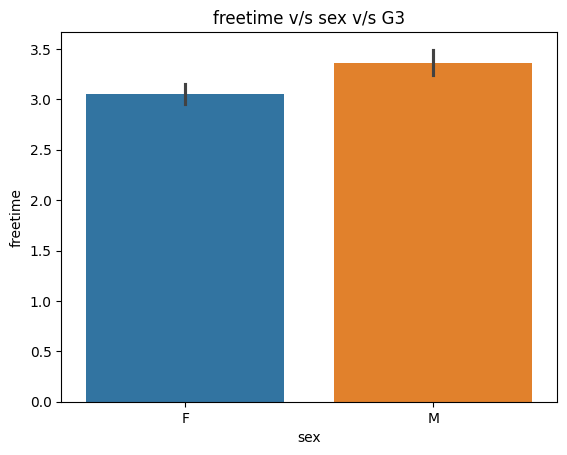

In [ ]:
sns.barplot(data=df,x='sex',y='freetime',hue='sex')
plt.title("freetime v/s sex v/s G3")
plt.show()

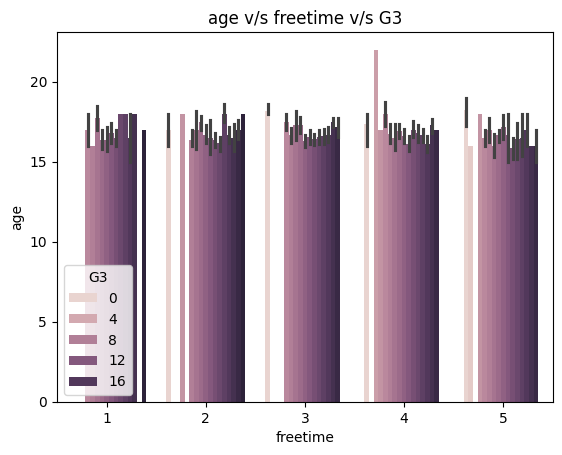

In [ ]:
sns.barplot(data=df,x='freetime',y='age',hue='G3')
plt.title("age v/s freetime v/s G3")
plt.show()

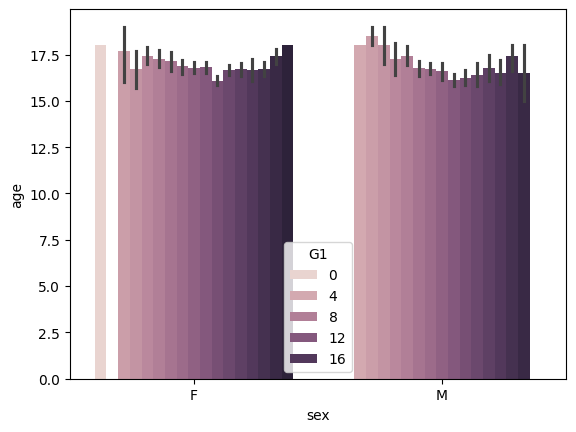

In [ ]:
sns.barplot(data=df,x='sex',y='age',hue='G1')
plt.show()

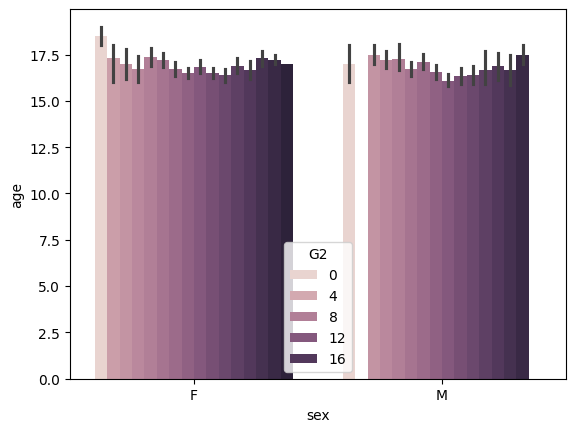

In [ ]:
sns.barplot(data=df,x='sex',y='age',hue='G2')
plt.show()

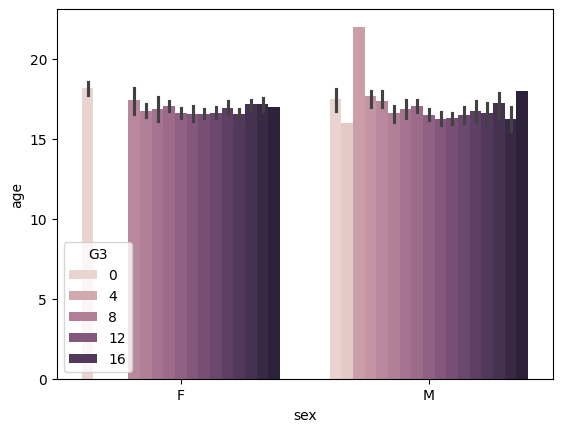

In [ ]:
sns.barplot(data=df,x='sex',y='age',hue='G3')
plt.show()

# feature engineering

# data encoding
* label encoding
* one-hot encoding
* target encoding

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [ ]:
object_cols = df.select_dtypes(include=['object']).columns
print(object_cols)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [ ]:
for col in object_cols:
    # Try converting to numeric, set errors='coerce' to convert non-convertible values to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
print(df.dtypes)  # See which columns are now float64 or numeric
print(df.head())

school        float64
sex           float64
age             int64
address       float64
famsize       float64
Pstatus       float64
Medu            int64
Fedu            int64
Mjob          float64
Fjob          float64
reason        float64
guardian      float64
traveltime      int64
studytime       int64
failures        int64
schoolsup     float64
famsup        float64
paid          float64
activities    float64
nursery       float64
higher        float64
internet      float64
romantic      float64
famrel          int64
freetime        int64
goout           int64
Dalc            int64
Walc            int64
health          int64
absences        int64
G1              int64
G2              int64
G3              int64
dtype: object
   school  sex  age  address  famsize  Pstatus  Medu  Fedu  Mjob  Fjob  ...  \
0     NaN  NaN   18      NaN      NaN      NaN     4     4   NaN   NaN  ...   
1     NaN  NaN   17      NaN      NaN      NaN     1     1   NaN   NaN  ...   
2     NaN  NaN   15    

In [ ]:
df[col].fillna(0, inplace=True)

<ipython-input-37-4239910893>:1: ChainedAssignmentError: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
When using the Copy-on-Write mode, such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object.


  df[col].fillna(0, inplace=True)


# Label Encoding

In [ ]:
Ib_sex = LabelEncoder()
df['sex'] = Ib_sex.fit_transform(df['sex'])

In [ ]:
Ib_address = LabelEncoder()
df['address'] = Ib_address.fit_transform(df['address'])

In [ ]:
Ib_Pstatus = LabelEncoder()
df['Pstatus'] = Ib_Pstatus.fit_transform(df['Pstatus'])

In [ ]:
Ib_school = LabelEncoder()
df['school'] = Ib_school.fit_transform(df['school'])

In [ ]:
Ib_famsize = LabelEncoder()
df['famsize'] = Ib_famsize.fit_transform(df['famsize'])

In [ ]:
Ib_si = LabelEncoder()
df['Mjob'] = Ib_si.fit_transform(df['Mjob'])

In [ ]:
Ib_sim = LabelEncoder()
df['Fjob'] = Ib_sim.fit_transform(df['Fjob'])

In [ ]:
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,0,0,0,4,4,0,0,...,4,3,4,1,1,3,4,0,11,11
1,0,0,17,0,0,0,1,1,0,0,...,5,3,3,1,1,3,2,9,11,11
2,0,0,15,0,0,0,1,1,0,0,...,4,3,2,2,3,3,6,12,13,12
3,0,0,15,0,0,0,4,2,0,0,...,3,2,2,1,1,5,0,14,14,14
4,0,0,16,0,0,0,3,3,0,0,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,0,0,19,0,0,0,2,3,0,0,...,5,4,2,1,2,5,4,10,11,10
645,0,0,18,0,0,0,3,1,0,0,...,4,3,4,1,1,1,4,15,15,16
646,0,0,18,0,0,0,1,1,0,0,...,1,1,1,1,1,5,6,11,12,9
647,0,0,17,0,0,0,3,1,0,0,...,2,4,5,3,4,2,6,10,10,10


# Handling outlayers

In [ ]:
import pandas as pd

# Assume df is your DataFrame
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [ ]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers

for col in numeric_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"Outliers in {col}: {len(outliers)}")

Outliers in school: 0
Outliers in sex: 0
Outliers in age: 1
Outliers in address: 0
Outliers in famsize: 0
Outliers in Pstatus: 0
Outliers in Medu: 0
Outliers in Fedu: 0
Outliers in Mjob: 0
Outliers in Fjob: 0
Outliers in reason: 0
Outliers in guardian: 0
Outliers in traveltime: 16
Outliers in studytime: 35
Outliers in failures: 100
Outliers in schoolsup: 0
Outliers in famsup: 0
Outliers in paid: 0
Outliers in activities: 0
Outliers in nursery: 0
Outliers in higher: 0
Outliers in internet: 0
Outliers in romantic: 0
Outliers in famrel: 51
Outliers in freetime: 45
Outliers in goout: 0
Outliers in Dalc: 34
Outliers in Walc: 0
Outliers in health: 0
Outliers in absences: 21
Outliers in G1: 16
Outliers in G2: 25
Outliers in G3: 16


In [ ]:
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]
    return filtered_data

for col in numeric_cols:
    df = remove_outliers_iqr(df, col)

In [ ]:
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = data[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return data

for col in numeric_cols:
    df = cap_outliers(df, col)

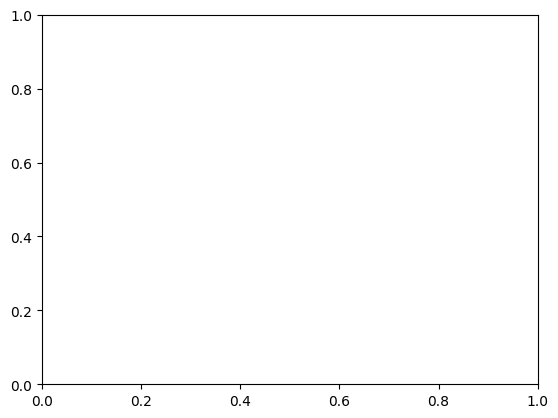

In [ ]:
sns.boxplot(x=df['absences'])
plt.show()

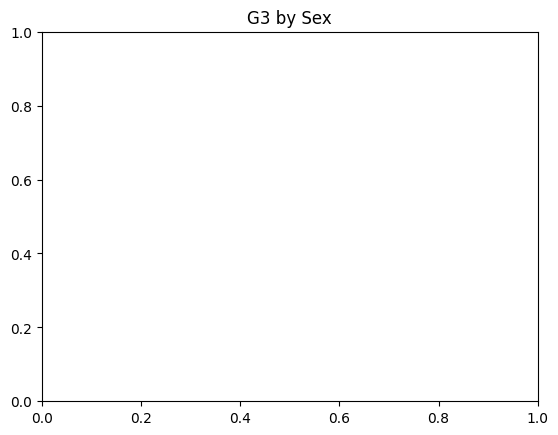

In [ ]:
# Example: Boxplot of G3 grouped by sex
sns.boxplot(data=df, x='sex', y='G3')
plt.title('G3 by Sex')
plt.show()

# checking for corelation

In [ ]:
df.dtypes

,0
school,int64
sex,int64
age,int64
address,int64
famsize,int64
Pstatus,int64
Medu,int64
Fedu,int64
Mjob,int64
Fjob,int64


In [ ]:
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=[np.number])

/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


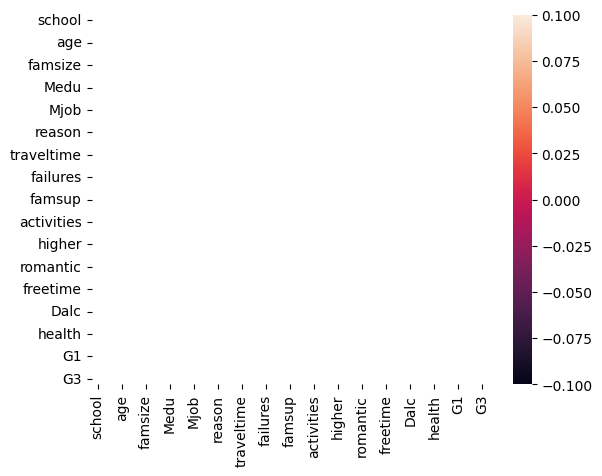

In [ ]:
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

Handling outliers by capping...


<ipython-input-55-906045258>:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound
<ipython-input-55-906045258>:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound
<ipython-input-55-906045258>:74: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-1.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data[col] < lower_bound, col] = lower_bound
<ipython-input-55-906045258>:74: FutureWarning: Setting an item of inc

Outlier capping complete.


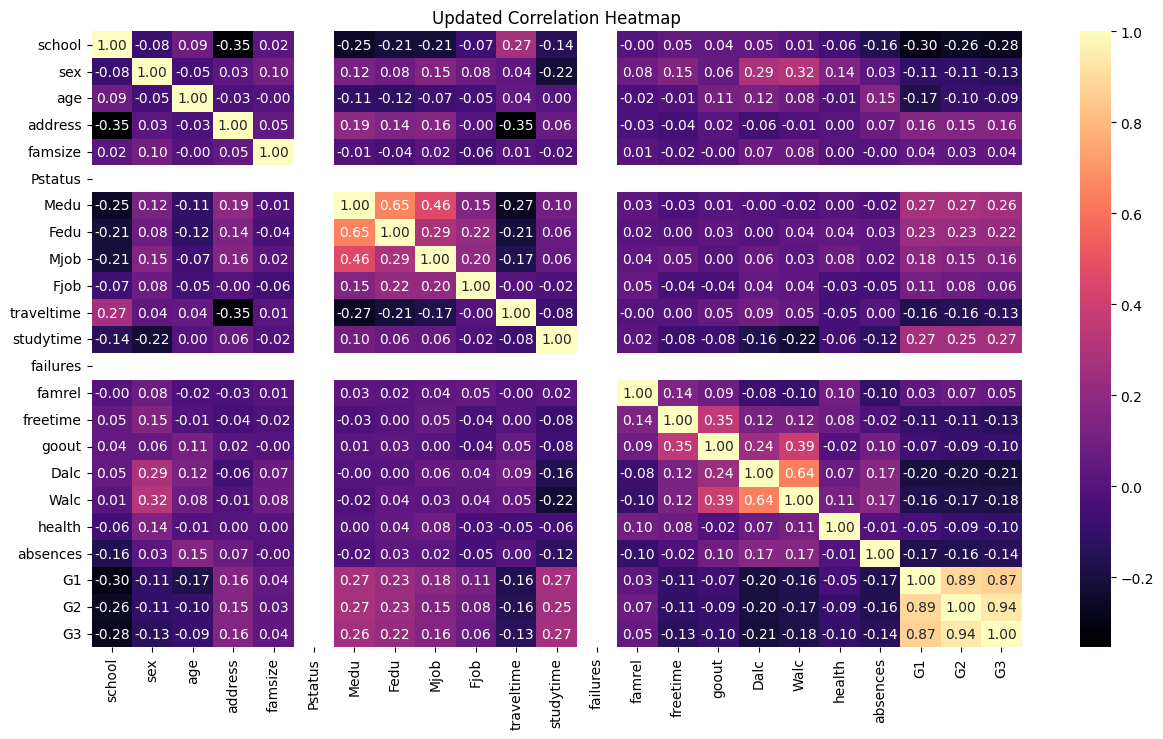

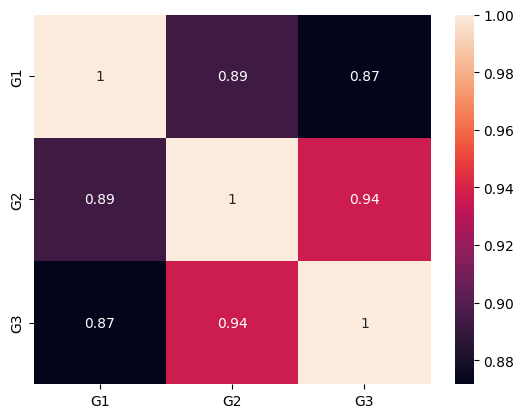

(519, 2)
(130, 2)
(519,)
(130,)
KNN Train Score: 0.8882629552972126
KNN Test Score: 0.860598865953465
KNN MSE: 1.1812307692307693
KNN R² Score: 0.860598865953465
Intercept: 12.018208596630888
Slope(s): [0.6175541  2.20841244]
Linear Regression Train Score: 0.8786411658683871
Linear Regression Test Score: 0.8974597472410512
Decision Tree Train Score: 0.9056889995891477
Decision Tree Test Score: 0.8679105736558361

Decision Tree RMSE:  1.058
Decision Tree R² Score: 0.8679105736558361
Decision Tree Mean Squared Error: 1.1192742136206886


In [ ]:
# Replace the outlier removal loop with outlier capping
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
pd.options.mode.copy_on_write = True
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
# Import the DecisionTreeRegressor for the later section
from sklearn.tree import DecisionTreeRegressor


df=pd.read_csv("/content/drive/MyDrive/student-por.csv")

# Data Preprocessing Steps (as in the original notebook)
object_cols = df.select_dtypes(include=['object']).columns
for col in object_cols:
    # Try converting to numeric, set errors='coerce' to convert non-convertible values to NaN
    # This step seems incorrect if the goal is to encode categorical data.
    # Let's revert this and perform proper encoding later if needed.
    # df[col] = pd.to_numeric(df[col], errors='coerce')
    pass # Skip this incorrect conversion

# Re-apply Label Encoding for the categorical columns identified earlier
# Ensure the columns are still of object type if the above conversion was skipped.
# Check dtypes before encoding
# print(df.dtypes)

# If columns are still object type, apply LabelEncoder
if 'sex' in df.columns and df['sex'].dtype == 'object':
    Ib_sex = LabelEncoder()
    df['sex'] = Ib_sex.fit_transform(df['sex'])
if 'address' in df.columns and df['address'].dtype == 'object':
    Ib_address = LabelEncoder()
    df['address'] = Ib_address.fit_transform(df['address'])
if 'Pstatus' in df.columns and df['Pstatus'].dtype == 'object':
    Ib_Pstatus = LabelEncoder()
    df['Pstatus'] = Ib_Pstatus.fit_transform(df['Pstatus'])
if 'school' in df.columns and df['school'].dtype == 'object':
    Ib_school = LabelEncoder()
    df['school'] = Ib_school.fit_transform(df['school'])
if 'famsize' in df.columns and df['famsize'].dtype == 'object':
    Ib_famsize = LabelEncoder()
    df['famsize'] = Ib_famsize.fit_transform(df['famsize'])
if 'Mjob' in df.columns and df['Mjob'].dtype == 'object':
    Ib_si = LabelEncoder()
    df['Mjob'] = Ib_si.fit_transform(df['Mjob'])
if 'Fjob' in df.columns and df['Fjob'].dtype == 'object':
    Ib_sim = LabelEncoder()
    df['Fjob'] = Ib_sim.fit_transform(df['Fjob'])

# The fillna(0, inplace=True) step was likely intended for the coerced numeric columns.
# Since we are skipping the coerce to numeric step for object columns,
# we need to reconsider how missing values are handled if there are any.
# Assuming no missing values based on df.isnull().sum() output earlier.

# Handling outliers - Use capping instead of removing rows
print("Handling outliers by capping...")
numeric_cols = df.select_dtypes(include=[np.number]).columns

def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Use .loc to avoid SettingWithCopyWarning
    data.loc[data[col] < lower_bound, col] = lower_bound
    data.loc[data[col] > upper_bound, col] = upper_bound
    return data

for col in numeric_cols:
    df = cap_outliers(df, col)

print("Outlier capping complete.")
# You can re-check boxplots here to see the effect of capping

# Continue with the rest of the notebook code from creating df_new onwards

# checking for corelation
# Select only numeric columns for correlation calculation
# Re-select numeric columns after encoding/capping
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(15, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='magma', cbar=True)
plt.title("Updated Correlation Heatmap")
plt.show()

# Drop columns with too many missing values if any were created (though unlikely here)
df = df.dropna(axis=1, thresh=int(0.8 * len(df)))

# Recompute and plot correlation heatmap if columns were dropped
# numeric_df = df.select_dtypes(include=[np.number]) # Re-select after dropping columns
# corr = numeric_df.corr()
# plt.figure(figsize=(15, 8))
# sns.heatmap(corr, annot=True, fmt=".2f", cmap='magma', cbar=True)
# plt.title("Updated Correlation Heatmap after dropping columns")
# plt.show()


# Now create df_new *after* outlier handling on the main df
df_new = df[['G1','G2','G3']].copy() # Use .copy() to avoid SettingWithCopyWarning later

# multicorelation
sns.heatmap(df_new.corr(),annot=True)
plt.show()

# data scailing
# Apply StandardScaler to df_new columns G1 and G2
g1_std = StandardScaler()
df_new['G1'] = g1_std.fit_transform(df_new[['G1']])

g2_std = StandardScaler()
df_new['G2'] = g2_std.fit_transform(df_new[['G2']])

# model building
x=df_new.drop('G3',axis=1)
y=df_new['G3']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

# knn
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)
print("KNN Train Score:", knn.score(x_train,y_train))
print("KNN Test Score:", knn.score(x_test,y_test))
y_pred_knn=knn.predict(x_test)
print("KNN MSE:", mean_squared_error(y_test, y_pred_knn))
print("KNN R² Score:", r2_score(y_test, y_pred_knn))


# linear regression
lin = LinearRegression()
lin.fit(x_train, y_train) # Fit on train data
print("Intercept:", lin.intercept_)
print("Slope(s):", lin.coef_)
print("Linear Regression Train Score:", lin.score(x_train,y_train))
print("Linear Regression Test Score:", lin.score(x_test,y_test))


# decision tree
# Make sure DecisionTreeRegressor is imported at the beginning
dec = DecisionTreeRegressor(random_state = 0)
dec.fit(x_train, y_train)
print("Decision Tree Train Score:", dec.score(x_train,y_train))
print("Decision Tree Test Score:", dec.score(x_test,y_test))
y_pred_dec = dec.predict(x_test)
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_dec)), '.3f'))
print("\nDecision Tree RMSE: ", rmse)
r2 = r2_score(y_test, y_pred_dec)
mse = mean_squared_error(y_test, y_pred_dec)
print("Decision Tree R² Score:", r2)
print("Decision Tree Mean Squared Error:", mse)

In [ ]:
df_new = df[['G1','G2','G3']]

#multicorelation

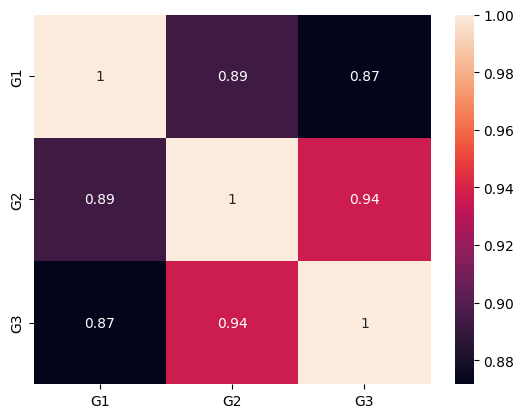

In [ ]:
sns.heatmap(df_new.corr(),annot=True)
plt.show()

#data scailing

In [ ]:
g1_std = StandardScaler()
df_new['G1'] = g1_std.fit_transform(df_new[['G1']])

In [ ]:
g2_std = StandardScaler()
df_new['G2'] = g2_std.fit_transform(df_new[['G2']])

# model building

In [ ]:
df_new

,G1,G2,G3
0,-2.206630,-0.230013,11
1,-0.899455,-0.230013,11
2,0.220979,0.513590,12
3,0.967936,0.885391,14
4,-0.152499,0.513590,13
...,...,...,...
644,-0.525977,-0.230013,10
645,1.341414,1.257192,16
646,-0.152499,0.141789,9
647,-0.525977,-0.601814,10


In [ ]:
x=df_new.drop('G3',axis=1)
y=df_new['G3']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(519, 2)
(130, 2)
(519,)
(130,)


# knn

In [ ]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsRegressor()

In [ ]:
knn.score(x_train,y_train)

0.8882629552972126

In [ ]:
knn.score(x_test,y_test)

0.860598865953465

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([17.4, 11.4, 18. , 11.2, 12.2, 16. , 17. , 10.2, 10.4, 10.8, 18. ,
       12.2, 12.6, 10.2, 12.6, 13.4, 11.2,  7. , 15.6, 14.6, 15.2, 13.2,
       13.2, 12.4, 15.2, 13.6,  9.4, 11.2, 11.4, 15.6, 16.4, 13.6,  7.4,
        6.2, 17.4, 15.2, 14. , 14.6, 13.4, 11.4, 13.4, 10.8,  7.4, 11.2,
       13.6, 13.6, 17.8, 11.4, 12.2, 11.2, 11.2, 10.8, 14.6, 10. , 11.2,
       17. ,  9.2, 11.2, 11.2, 10.2,  9.6, 11.4, 16. , 12.2, 15.2, 15.6,
       10. ,  9.2, 10.2,  9.6, 15.6, 15.6, 12.4, 16.8, 13.4, 13.2, 12.6,
       15. , 12.4, 13.2, 11.2, 11.4, 16.2,  7.8, 12.2, 18. , 12.2,  9. ,
       15.8, 12.2, 15.6,  9.2, 11.2, 18. ,  9.8, 15.8, 15.6,  9.2, 12.6,
        9.6, 12.2, 11. , 11.2, 11.2, 12.2, 10.8, 10.8, 11.2,  9.6, 13.4,
       13.4,  8. , 12.2, 10.8,  4.8, 10.4, 10.8, 16.8, 15.2,  9.2, 13.4,
        5.6, 15.6, 15. , 12.2,  5.6, 17.4, 10. , 13. ,  7.4])

In [ ]:
r2=r2_score(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

MSE: 1.1812307692307693
R² Score: 0.860598865953465


# linear regression

In [ ]:
lin = LinearRegression()
lin.fit(x, y)

LinearRegression()

In [ ]:
print("Intercept:", lin.intercept_)
print("Slope(s):", lin.coef_)

Intercept: 12.003081664098612
Slope(s): [0.50697653 2.27693663]


In [ ]:
lin.score(x_train,y_train)

0.8782373744036762

In [ ]:
lin.score(x_test,y_test)

0.901198622749706

# decision tree

In [ ]:
dec = DecisionTreeRegressor(random_state = 0)

In [ ]:
dec.fit(x_train, y_train)

DecisionTreeRegressor(random_state=0)

In [ ]:
dec.score(x_train,y_train)

0.9056889995891477

In [ ]:
dec.score(x_test,y_test)

0.8679105736558361

In [ ]:
y_pred_dec = dec.predict(x_test)

In [ ]:
rmse = float(format(np.sqrt(mean_squared_error(y_test, y_pred_dec)), '.3f'))
print("\nRMSE: ", rmse)


RMSE:  1.058


In [ ]:
r2 = r2_score(y_test, y_pred_dec)
mse = mean_squared_error(y_test, y_pred_dec)
print("R² Score:", r2)
print("Mean Squared Error:", mse)

R² Score: 0.8679105736558361
Mean Squared Error: 1.1192742136206886


# random forest

In [ ]:
iris = load_iris()
x = iris.data
y = iris.target

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf.fit(x_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf.score(x_train,y_train)

0.9045920648134891

In [ ]:
rf.score(x_test,y_test)

0.870942213006843

In [ ]:
y_pred_rf = rf.predict(x_test)

In [ ]:
r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)